In [1]:
import tensorflow as tf 
import numpy as np
gpus = tf.config.list_physical_devices("GPU")

print(gpus)

import import_data

2025-04-02 18:05:37.865109: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-02 18:05:37.894497: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-02 18:05:37.894517: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-02 18:05:37.895330: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-02 18:05:37.901201: I tensorflow/core/platform/cpu_feature_guar

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
data ['Simulation_01_210209_001_002', 'LA_RSPV_CAF_150115', 'Simulation_01_200428_001_001', 'Simulation_01_201223_001_002', 'Simulation_01_190619_001_004', 'Simulation_01_190502_001_004', 'RA_RAFW_140807', 'RA_RAA_141230', 'Simulation_01_200316_001_  1', 'TwoRotors_181219', 'RA_RAFW_SAF_140730', 'Simulation_01_200212_001_  4']

Egms models LOADED - var: **egms_all_models**, **egms_values** 
EGMS data normalized - var: **egms_filtered_norm** 
Transfer matrices LOADED - var: **transfer_matrices** 
BSPS Models LOADED - var: **bsps_all_models** 
BSPS 64 Models LOADED - var: **bsps_64_all_models** 


In [2]:
import scatt_all_models

Num GPUs Available:  2
All models have been trimmed to the minimum length - var: **bsps_64_models_trimmed** 

Model: Simulation_01_210209_001_002
Samples of every node: 1301 samples
Shape del tensor de Simulation_01_210209_001_002: (64, 74, 81)

Model: LA_RSPV_CAF_150115
Samples of every node: 1301 samples
Shape del tensor de LA_RSPV_CAF_150115: (64, 74, 81)

Model: Simulation_01_200428_001_001
Samples of every node: 1301 samples
Shape del tensor de Simulation_01_200428_001_001: (64, 74, 81)

Model: Simulation_01_201223_001_002
Samples of every node: 1301 samples
Shape del tensor de Simulation_01_201223_001_002: (64, 74, 81)

Model: Simulation_01_190619_001_004
Samples of every node: 1301 samples
Shape del tensor de Simulation_01_190619_001_004: (64, 74, 81)

Model: Simulation_01_190502_001_004
Samples of every node: 1301 samples
Shape del tensor de Simulation_01_190502_001_004: (64, 74, 81)

Model: RA_RAFW_140807
Samples of every node: 1301 samples
Shape del tensor de RA_RAFW_140807: 

In [3]:
egms_all_models = import_data.egms_all_models
egms_values = import_data.egms_values
egms_filtered_norm = import_data.egms_filtered_norm
bsps_all_models = import_data.bsps_all_models
bsps_64_all_models = import_data.bsps_64_all_models
transfer_matrices = import_data.transfer_matrices

bsps_64_models_trimmed = scatt_all_models.bsps_64_models_trimmed
ws_coeff_all_mods = scatt_all_models.ws_coeff_all_mods
sinusal_groups = scatt_all_models.sinusal_groups
rotor_simple_groups = scatt_all_models.rotor_simple_groups
rotor_complejo_groups = scatt_all_models.rotor_complejo_groups
models_name = scatt_all_models.models_name

In [4]:
print(models_name)

['Simulation_01_210209_001_002', 'LA_RSPV_CAF_150115', 'Simulation_01_200428_001_001', 'Simulation_01_201223_001_002', 'Simulation_01_190619_001_004', 'Simulation_01_190502_001_004', 'RA_RAFW_140807', 'RA_RAA_141230', 'Simulation_01_200316_001_  1', 'TwoRotors_181219', 'RA_RAFW_SAF_140730', 'Simulation_01_200212_001_  4']


In [10]:
labels = []
print(len(ws_coeff_all_mods))
for model, name_model in zip(ws_coeff_all_mods, models_name):
    if name_model in sinusal_groups:
        print(f"Model {name_model} is a sinusal group")
        labels.append(0)
    elif name_model in rotor_simple_groups:
        print(f"Model {name_model} is a rotor simple group")
        labels.append(1)
    elif name_model in rotor_complejo_groups:
        print(f"Model {name_model} is a rotor complejo group")
        labels.append(1)
    else:
        print(f"Model {name_model} is not in any group --> AF")
        labels.append(1)


12
Model Simulation_01_210209_001_002 is a sinusal group
Model LA_RSPV_CAF_150115 is a rotor complejo group
Model Simulation_01_200428_001_001 is a sinusal group
Model Simulation_01_201223_001_002 is a sinusal group
Model Simulation_01_190619_001_004 is not in any group --> AF
Model Simulation_01_190502_001_004 is not in any group --> AF
Model RA_RAFW_140807 is a rotor complejo group
Model RA_RAA_141230 is a rotor complejo group
Model Simulation_01_200316_001_  1 is a sinusal group
Model TwoRotors_181219 is a rotor complejo group
Model RA_RAFW_SAF_140730 is a rotor complejo group
Model Simulation_01_200212_001_  4 is not in any group --> AF


In [ ]:
print(labels)

[0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1]


Text(0, 0.5, 'Amplitude')

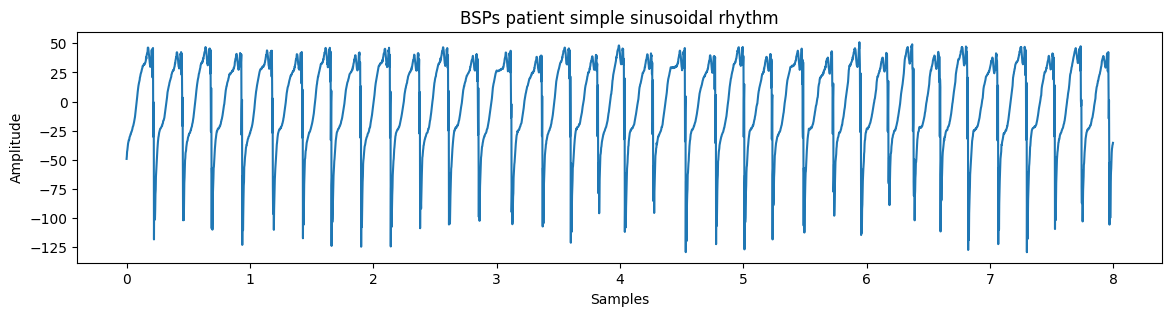

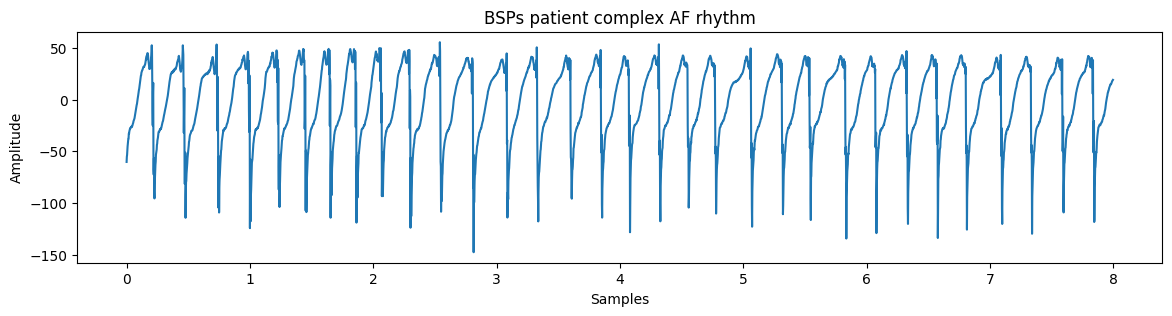

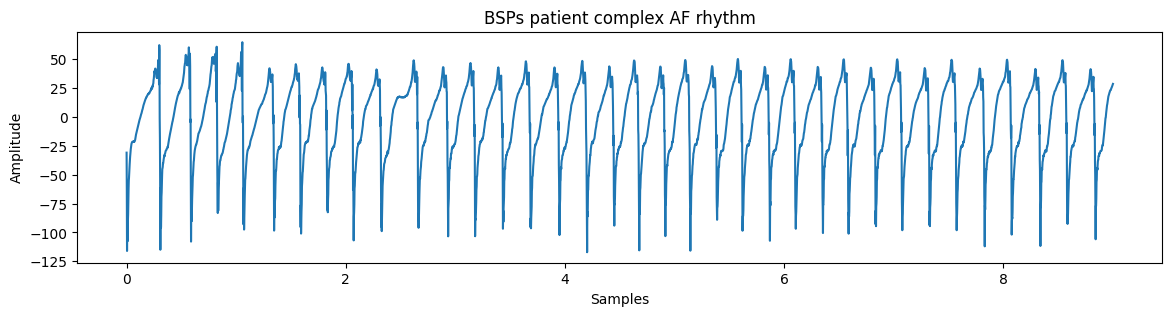

In [8]:
import matplotlib.pyplot as plt
egms_values_4 = egms_values[4]
signal_4 = egms_values_4[0,:]-np.mean(egms_values_4[0,:])

egms_values_5 = egms_values[5]
signal_5 = egms_values_5[0,:]-np.mean(egms_values_5[0,:])

egms_values_11 = egms_values[11]
signal_11 = egms_values_11[0,:]-np.mean(egms_values_11[0,:])


fs = 500
t_4 = np.arange(len(signal_4))/fs
t_5  = np.arange(len(signal_5))/fs
t_11 = np.arange(len(signal_11))/fs

plt.figure(figsize=(14, 3))
plt.plot(t_4, signal_4)
plt.title("BSPs patient simple sinusoidal rhythm")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.figure(figsize=(14, 3))
plt.plot(t_5, signal_5)
plt.title("BSPs patient complex AF rhythm")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.figure(figsize=(14, 3))
plt.plot(t_11, signal_11)
plt.title("BSPs patient complex AF rhythm")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

##### **MODELO BASICO CLASSIFICATION CON TENSORES** --> RED CONVOLUCIONAL (3 capas, 16 filtros)
* INPUT: tensores coefficients de scattering de 16 nodos 
* From SIMPLE model --> 4 tensors of 16 nodes each one (1 tensor = 1 patient)
* From COMPLEX model --> 4 tensors of 16 nodes each one (1 tensor = 1 patient)
* INPUT --> 8 tensors with 16 node's scattering coefficients (size 74x125), to be classified into AF (1) or simple sinusoidal rhythm (0)

In [36]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

ws_coeff_all_mods = np.array(ws_coeff_all_mods)
print(ws_coeff_all_mods.shape)

X = ws_coeff_all_mods # (N, ?, ?)

# Crear etiquetas (0 = normal, 1 = AF)
y = np.array(labels)

print("X shape:", X.shape)  # Verificar la dimensión de entrada
print("y shape:", y.shape)  # Verificar las etiquetas
print("y:", y)  # Revisar algunas etiquetas

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape, "X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape, "y_test shape:", y_test.shape)

(12, 64, 74, 81)
X shape: (12, 64, 74, 81)
y shape: (12,)
y: [0 1 0 0 1 1 1 1 0 1 1 1]
X_train shape: (9, 64, 74, 81) X_test shape: (3, 64, 74, 81)
y_train shape: (9,) y_test shape: (3,)


In [37]:
print("Shape of X_train before transposition:", X_train.shape)
print("Shape of X_test before transposition:", X_test.shape)

X_train = np.transpose(X_train, (0, 2, 3, 1))  # (samples, height, width, channels)
X_test = np.transpose(X_test, (0, 2, 3, 1))    # (samples, height, width, channels)

print("X_train shape:", X_train.shape)  # (6, 74, 125, 16)
print("X_test shape:", X_test.shape)    # (2, 74, 125, 16)

Shape of X_train before transposition: (9, 64, 74, 81)
Shape of X_test before transposition: (3, 64, 74, 81)
X_train shape: (9, 74, 81, 64)
X_test shape: (3, 74, 81, 64)


In [38]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


model = keras.Sequential([
    layers.Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding="same", input_shape=X_train.shape[1:]),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding="same"),
    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(2, activation='softmax')  # Dos clases: 0 y 1
])

# Compilar el modelo
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])  

# Resumen del modelo
model.summary()


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 74, 81, 16)        9232      
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 37, 40, 16)        0         
 g2D)                                                            
                                                                 
 conv2d_7 (Conv2D)           (None, 37, 40, 32)        4640      
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 18, 20, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_8 (Conv2D)           (None, 18, 20, 64)        18496     
                                                                 
 flatten_2 (Flatten)         (None, 23040)            

In [39]:
history = model.fit(X_train, y_train, epochs=40, batch_size=16, validation_split=0.2)

Epoch 1/40
1/1 [==============================] - 1s 1s/step - loss: 0.6931 - accuracy: 0.4286 - val_loss: 0.6883 - val_accuracy: 1.0000
Epoch 2/40
1/1 [==============================] - 0s 41ms/step - loss: 0.6900 - accuracy: 0.5714 - val_loss: 0.6530 - val_accuracy: 1.0000
Epoch 3/40
1/1 [==============================] - 0s 43ms/step - loss: 0.6891 - accuracy: 0.5714 - val_loss: 0.5981 - val_accuracy: 1.0000
Epoch 4/40
1/1 [==============================] - 0s 42ms/step - loss: 0.6876 - accuracy: 0.5714 - val_loss: 0.5441 - val_accuracy: 1.0000
Epoch 5/40
1/1 [==============================] - 0s 41ms/step - loss: 0.7053 - accuracy: 0.5714 - val_loss: 0.5344 - val_accuracy: 1.0000
Epoch 6/40
1/1 [==============================] - 0s 40ms/step - loss: 0.6715 - accuracy: 0.5714 - val_loss: 0.5158 - val_accuracy: 1.0000
Epoch 7/40
1/1 [==============================] - 0s 43ms/step - loss: 0.7128 - accuracy: 0.4286 - val_loss: 0.5325 - val_accuracy: 1.0000
Epoch 8/40
1/1 [=============

In [40]:
# Evaluación del modelo en el conjunto de test
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Precisión en test: {test_acc:.2%}")

1/1 [==============================] - 0s 26ms/step - loss: 0.7027 - accuracy: 0.6667
Precisión en test: 66.67%


In [41]:
# Selecciono señal de prueba
sample = X_test[0:1]  # Primera muestra de test
pred = model.predict(sample)
print("Probabilidades:", pred)

# Clase predicha (0 = normal, 1 = AF)
pred_class = np.argmax(pred)
print(f"Predicción: {'Normal' if pred_class == 0 else 'AF'}")

1/1 [==============================] - 0s 59ms/step
Probabilidades: [[0.361994 0.638006]]
Predicción: AF


In [42]:
real_class = y_test[0]  # La etiqueta real de la muestra seleccionada

# Comparar con la predicción
print(f"Etiqueta real: {'Normal' if real_class == 0 else 'AF'}")
if pred_class == real_class:
    print("Good Pred")
else:
    print("Wrong Pred")

Etiqueta real: Normal
Wrong Pred
